In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("../data/processed/telco_cleaned.csv")

from features import create_features
df = create_features(df)

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

In [31]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])

In [32]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [33]:
cv_results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="roc_auc")
    cv_results[name] = scores.mean()

cv_results

{'Logistic Regression': np.float64(0.8494673895366619),
 'Random Forest': np.float64(0.8235272695963778),
 'Gradient Boosting': np.float64(0.8434189615332404)}

In [34]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

In [36]:
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.8380499953158669
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.50      0.57       372

    accuracy                           0.80      1405
   macro avg       0.74      0.70      0.72      1405
weighted avg       0.79      0.80      0.79      1405



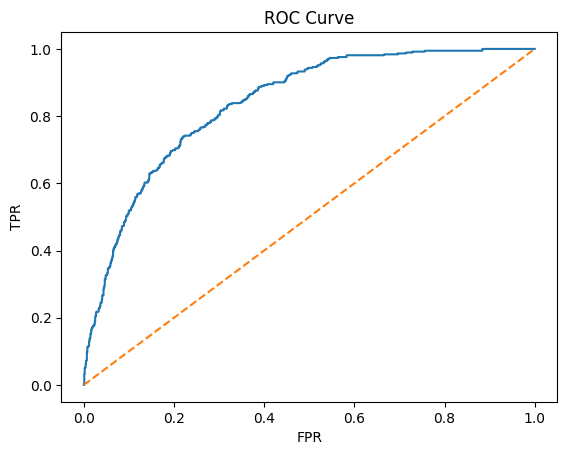

In [37]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [38]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.74      0.63       372

    accuracy                           0.77      1405
   macro avg       0.72      0.76      0.73      1405
weighted avg       0.80      0.77      0.78      1405


Threshold: 0.35
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1033
           1       0.58      0.67      0.62       372

    accuracy                           0.78      1405
   macro avg       0.73      0.75      0.73      1405
weighted avg       0.80      0.78      0.79      1405


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1033
           1       0.61      0.63      0.62       372

    accuracy                           0.79      1405
   macro avg       0.74      0.74      0.74      1405
weighted avg       0.80  

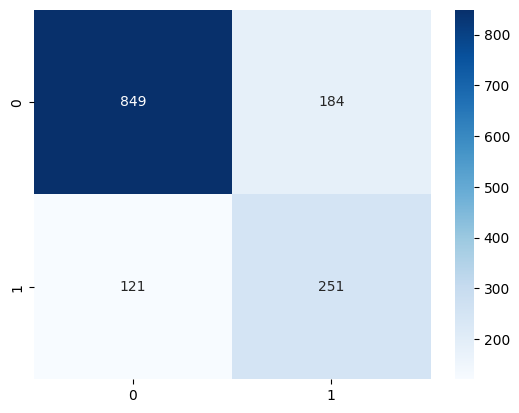

In [39]:
optimal_threshold = 0.35
final_pred = (y_proba >= optimal_threshold).astype(int)

cm = confusion_matrix(y_test, final_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()

In [40]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
importances = final_model.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(15)

,feature,importance
8,num__long_contract,0.372488
1,num__tenure,0.129858
2,num__MonthlyCharges,0.069773
3,num__TotalCharges,0.068824
18,cat__InternetService_Fiber optic,0.063680
36,cat__PaymentMethod_Electronic check,0.050748
10,num__avg_monthly_spend,0.044533
7,num__fiber_customer,0.040544
9,num__customer_lifetime_value,0.036180
34,cat__PaperlessBilling_Yes,0.015932
